## Training Setup 

##### Load and split

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from IPython.display import display


In [2]:
DATA_DIR = Path.cwd().resolve()

acc_data = np.load(DATA_DIR / "acc_features_full.npz", allow_pickle=True)
x_acc = acc_data["features"]
y_acc_raw = acc_data["labels"]

gyro_data = np.load(DATA_DIR / "gyro_features_full.npz", allow_pickle=True)
x_gyro = gyro_data["features"]
y_gyro_raw = gyro_data["labels"]

label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([np.asarray(y_acc_raw).astype(str), np.asarray(y_gyro_raw).astype(str)]))
y_acc = label_encoder.transform(np.asarray(y_acc_raw).astype(str))
y_gyro = label_encoder.transform(np.asarray(y_gyro_raw).astype(str))
class_names = list(label_encoder.classes_)

print('Accelerometer feature shape:', x_acc.shape)
print('Gyroscope feature shape:', x_gyro.shape)
print('Classes:', class_names)


Accelerometer feature shape: (212772, 64)
Gyroscope feature shape: (231391, 64)
Classes: [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5')]


In [3]:
# Stratified splits: 70% train, 10% validation, 20% test
x_acc_train, x_acc_test, y_acc_train, y_acc_test = train_test_split(
    x_acc, y_acc, test_size=0.2, random_state=42, stratify=y_acc
)
x_acc_train, x_acc_val, y_acc_train, y_acc_val = train_test_split(
    x_acc_train, y_acc_train, test_size=0.125, random_state=42, stratify=y_acc_train
)

x_gyro_train, x_gyro_test, y_gyro_train, y_gyro_test = train_test_split(
    x_gyro, y_gyro, test_size=0.2, random_state=42, stratify=y_gyro
)
x_gyro_train, x_gyro_val, y_gyro_train, y_gyro_val = train_test_split(
    x_gyro_train, y_gyro_train, test_size=0.125, random_state=42, stratify=y_gyro_train
)

print('Accelerometer splits:', x_acc_train.shape, x_acc_val.shape, x_acc_test.shape)
print('Gyroscope splits:', x_gyro_train.shape, x_gyro_val.shape, x_gyro_test.shape)


Accelerometer splits: (148939, 64) (21278, 64) (42555, 64)
Gyroscope splits: (161973, 64) (23139, 64) (46279, 64)


##### Scale the features

In [4]:
# Scale the features for training 
scaler_acc = StandardScaler()
x_acc_train_scaled = scaler_acc.fit_transform(x_acc_train)
x_acc_val_scaled = scaler_acc.transform(x_acc_val)
x_acc_test_scaled = scaler_acc.transform(x_acc_test)

scaler_gyro = StandardScaler()
x_gyro_train_scaled = scaler_gyro.fit_transform(x_gyro_train)
x_gyro_val_scaled = scaler_gyro.transform(x_gyro_val)
x_gyro_test_scaled = scaler_gyro.transform(x_gyro_test)

print('Scaled accelerometer shape:', x_acc_train_scaled.shape)
print('Scaled gyroscope shape:', x_gyro_train_scaled.shape)


Scaled accelerometer shape: (148939, 64)
Scaled gyroscope shape: (161973, 64)


# Classification Models

## Model Training and Validation

This section fits each model on the training split and evaluates performance only on the train and validation sets. The test split is kept completely separate until the final section.

In [5]:
class_dispname = ["Biking", "Sitting", "Standing", "Walking", "Stair Up", "Stair Down"]
class_names = class_dispname


def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
    }


def evaluate_models(X_train, y_train, X_val, y_val, sensor_name):
    rows = []
    fitted_models = {}
    for name, model in get_models().items():
        model.fit(X_train, y_train)
        fitted_models[name] = model
        for split_name, X_split, y_split in [('train', X_train, y_train), ('val', X_val, y_val)]:
            pred = model.predict(X_split)
            acc = accuracy_score(y_split, pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_split, pred, average='macro', zero_division=0
            )
            rows.append({
                'sensor': sensor_name,
                'model': name,
                'split': split_name,
                'accuracy': acc,
                'precision': precision,
                'recall': recall,
                'f1': f1,
            })
    return fitted_models, pd.DataFrame(rows)


def test_models(fitted_models, X_test, y_test, sensor_name, class_dispname):
    rows = []
    for name, model in fitted_models.items():
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, pred, average='macro', zero_division=0
        )
        rows.append({
            'sensor': sensor_name,
            'model': name,
            'split': 'test',
            'accuracy': acc,
            'precision': precision,
            'recall': recall,
            'f1': f1,
        })
        print(f'\n=== {sensor_name}: {name} - Test Set ===')
        print(classification_report(y_test, pred, zero_division=0, target_names=class_dispname))
    return pd.DataFrame(rows)


In [6]:
def plot_split_scores(results_df, sensor_name):
    summary = results_df.groupby(['model', 'split'])[['accuracy', 'precision', 'recall', 'f1']].mean().reset_index()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    split_order = [s for s in ['train', 'val', 'test'] if s in summary['split'].unique()]
    for ax, metric in zip(axes.ravel(), metrics):
        pivot = summary.pivot(index='model', columns='split', values=metric)
        pivot[split_order].plot(kind='bar', ax=ax)
        ax.set_title(f'{sensor_name} - {metric.capitalize()}')
        ax.set_ylabel(metric.capitalize())
        ax.set_xlabel('Model')
        ax.legend(title='Split')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(fitted_models, X_test, y_test, sensor_name, class_dispname, top_n=3):
    test_rows = []
    for name, model in fitted_models.items():
        pred = model.predict(X_test)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
        test_rows.append({'model': name, 'precision': precision, 'recall': recall, 'f1': f1})
    test_df = pd.DataFrame(test_rows).sort_values('f1', ascending=False).head(top_n)
    for name in test_df['model']:
        pred = fitted_models[name].predict(X_test)
        disp = ConfusionMatrixDisplay.from_predictions(
            y_test,
            pred,
            display_labels=class_dispname,
            xticks_rotation=45,
            cmap='Blues'
        )
        disp.ax_.set_title(f'{sensor_name} - {name} Confusion Matrix')
        plt.tight_layout()
        plt.show()
    return test_df


def plot_multiclass_roc(fitted_models, X_test, y_test, sensor_name, class_dispname, top_n=3):
    test_rows = []
    for name, model in fitted_models.items():
        pred = model.predict(X_test)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
        test_rows.append({'model': name, 'precision': precision, 'recall': recall, 'f1': f1})
    test_df = pd.DataFrame(test_rows).sort_values('f1', ascending=False).head(top_n)
    y_bin = label_binarize(y_test, classes=np.arange(len(class_dispname)))
    plt.figure(figsize=(10, 8))
    for name in test_df['model']:
        model = fitted_models[name]
        if hasattr(model, 'predict_proba'):
            scores = model.predict_proba(X_test)
        else:
            scores = model.decision_function(X_test)
            if scores.ndim == 1:
                scores = np.column_stack([1 - scores, scores])
        fpr, tpr, _ = roc_curve(y_bin.ravel(), scores.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{sensor_name} - ROC Curves')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


### Phone Accelerometer

,sensor,model,split,accuracy,precision,recall,f1
0,Accelerometer,Logistic Regression,train,0.945837,0.944805,0.944625,0.944655
1,Accelerometer,Logistic Regression,val,0.945719,0.944579,0.944562,0.944538
2,Accelerometer,Random Forest,train,1.000000,1.000000,1.000000,1.000000
3,Accelerometer,Random Forest,val,0.947598,0.946477,0.946730,0.946456
4,Accelerometer,KNN,train,0.968229,0.967571,0.967867,0.967597
5,Accelerometer,KNN,val,0.956011,0.955184,0.954938,0.954925


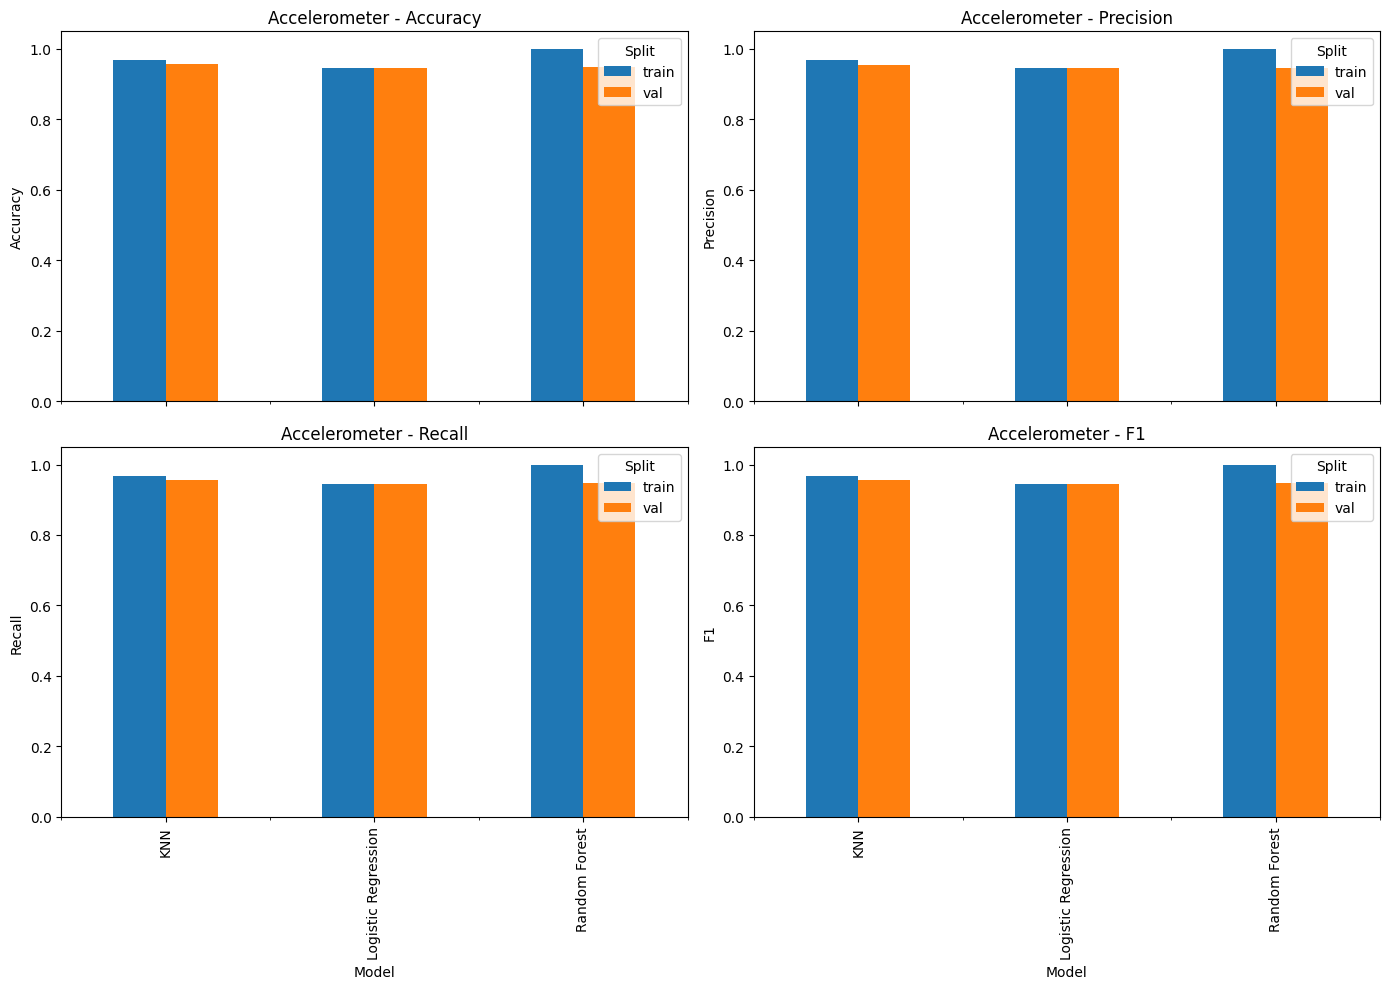

In [7]:
acc_models, acc_val_results = evaluate_models(
    x_acc_train_scaled, y_acc_train, x_acc_val_scaled, y_acc_val, 'Accelerometer'
)
display(acc_val_results)
plot_split_scores(acc_val_results, 'Accelerometer')


### Phone Gyroscope

,sensor,model,split,accuracy,precision,recall,f1
0,Gyroscope,Logistic Regression,train,0.849543,0.852409,0.845973,0.846584
1,Gyroscope,Logistic Regression,val,0.848740,0.851624,0.845167,0.845621
2,Gyroscope,Random Forest,train,1.000000,1.000000,1.000000,1.000000
3,Gyroscope,Random Forest,val,0.874541,0.873346,0.874036,0.873654
4,Gyroscope,KNN,train,0.910047,0.910360,0.909510,0.909818
5,Gyroscope,KNN,val,0.873244,0.873128,0.872142,0.872490


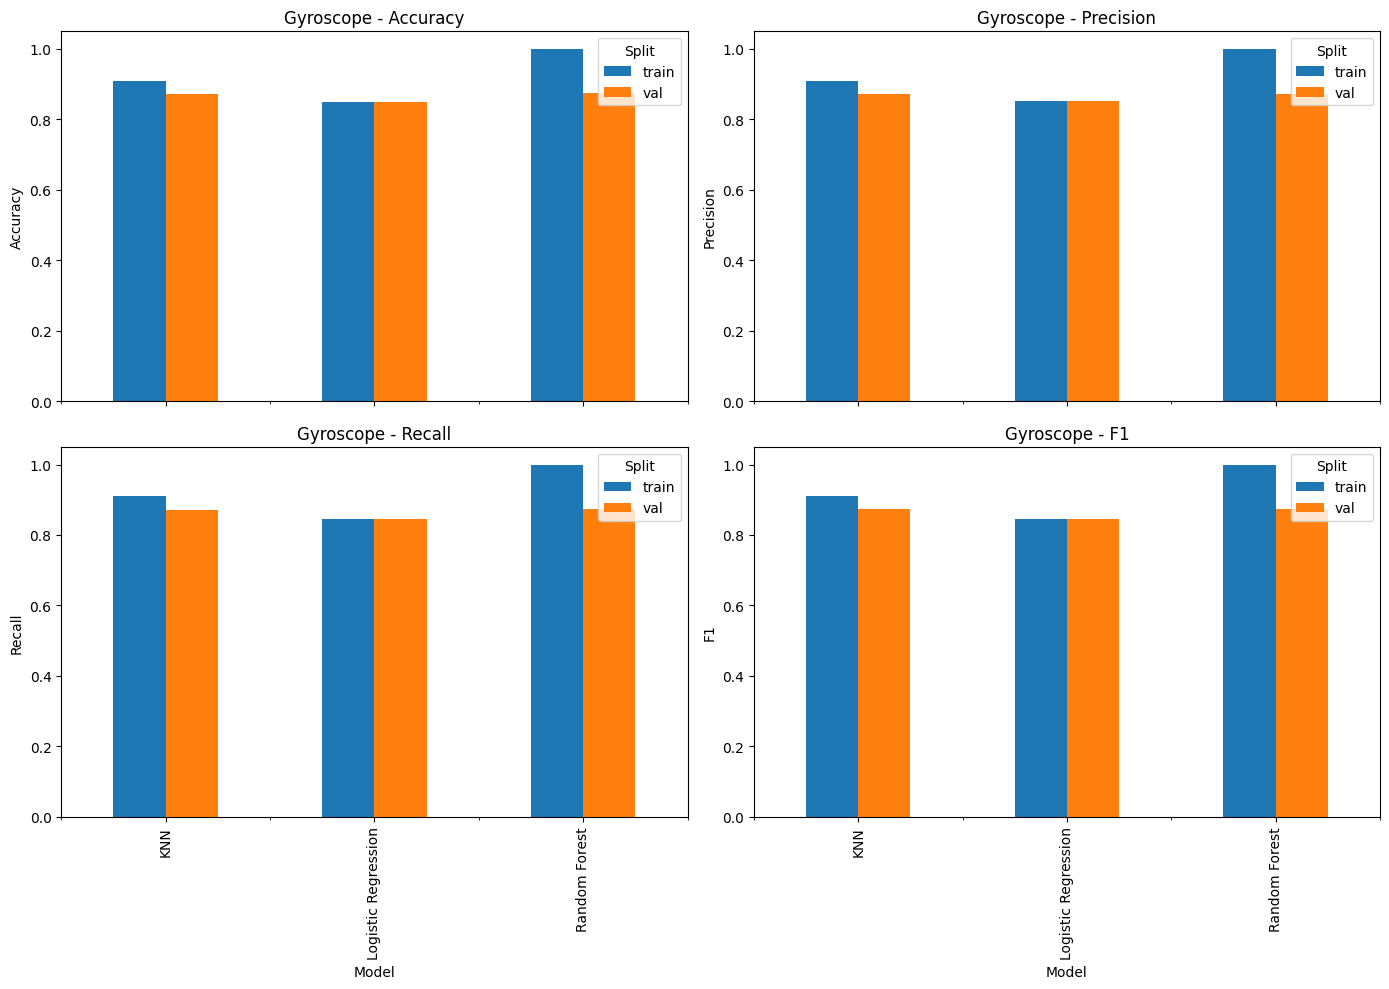

In [8]:
gyro_models, gyro_val_results = evaluate_models(
    x_gyro_train_scaled, y_gyro_train, x_gyro_val_scaled, y_gyro_val, 'Gyroscope'
)
display(gyro_val_results)
plot_split_scores(gyro_val_results, 'Gyroscope')


## Validation Comparison

The comparison below uses only the validation split to choose promising models before touching the test set.

,sensor,model,accuracy,precision,recall,f1
5,Accelerometer,KNN,0.956011,0.955184,0.954938,0.954925
3,Accelerometer,Random Forest,0.947598,0.946477,0.946730,0.946456
1,Accelerometer,Logistic Regression,0.945719,0.944579,0.944562,0.944538
3,Gyroscope,Random Forest,0.874541,0.873346,0.874036,0.873654
5,Gyroscope,KNN,0.873244,0.873128,0.872142,0.872490
1,Gyroscope,Logistic Regression,0.848740,0.851624,0.845167,0.845621


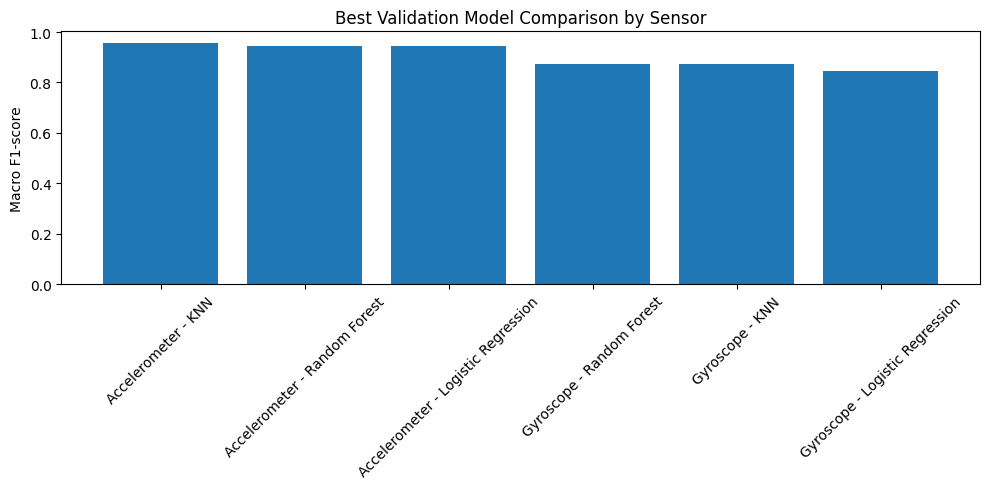

In [9]:
# Compare the best validation F1-score across sensors
acc_best_val = acc_val_results[acc_val_results['split'] == 'val'].sort_values('f1', ascending=False).drop_duplicates('model')
gyro_best_val = gyro_val_results[gyro_val_results['split'] == 'val'].sort_values('f1', ascending=False).drop_duplicates('model')
comparison_val = pd.concat([
    acc_best_val.assign(sensor='Accelerometer'),
    gyro_best_val.assign(sensor='Gyroscope')
])
display(comparison_val[['sensor', 'model', 'accuracy', 'precision', 'recall', 'f1']].sort_values(['sensor', 'f1'], ascending=[True, False]))

fig, ax = plt.subplots(figsize=(10, 5))
comparison_plot = comparison_val[['sensor', 'model', 'f1']].copy()
comparison_plot['label'] = comparison_plot['sensor'] + ' - ' + comparison_plot['model']
ax.bar(comparison_plot['label'], comparison_plot['f1'])
ax.set_ylabel('Macro F1-score')
ax.set_title('Best Validation Model Comparison by Sensor')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [10]:
# Save training and validation metrics tables so they can be reused in the report
results_dir = Path('processed')
results_dir.mkdir(parents=True, exist_ok=True)
acc_val_results.to_csv(results_dir / 'accelerometer_model_results_validation.csv', index=False)
gyro_val_results.to_csv(results_dir / 'gyroscope_model_results_validation.csv', index=False)


## Final Test Evaluation

Only after training and validation are complete do we evaluate the fitted models on the held-out test split. This keeps the final performance estimate unbiased.


=== Accelerometer: Logistic Regression - Test Set ===
              precision    recall  f1-score   support

      Biking       0.95      0.96      0.96      6328
     Sitting       0.99      1.00      0.99      7709
    Standing       0.90      0.88      0.89      6275
     Walking       0.89      0.91      0.90      6945
    Stair Up       0.99      0.98      0.99      6591
  Stair Down       0.95      0.94      0.94      8707

    accuracy                           0.95     42555
   macro avg       0.94      0.94      0.94     42555
weighted avg       0.95      0.95      0.95     42555


=== Accelerometer: Random Forest - Test Set ===
              precision    recall  f1-score   support

      Biking       0.95      0.96      0.96      6328
     Sitting       1.00      1.00      1.00      7709
    Standing       0.90      0.88      0.89      6275
     Walking       0.88      0.92      0.90      6945
    Stair Up       0.99      0.99      0.99      6591
  Stair Down       0.96     

,sensor,model,split,accuracy,precision,recall,f1
0,Accelerometer,Logistic Regression,test,0.945788,0.944599,0.944655,0.944588
1,Accelerometer,Random Forest,test,0.947409,0.946218,0.946738,0.946329
2,Accelerometer,KNN,test,0.956339,0.955445,0.955802,0.955480


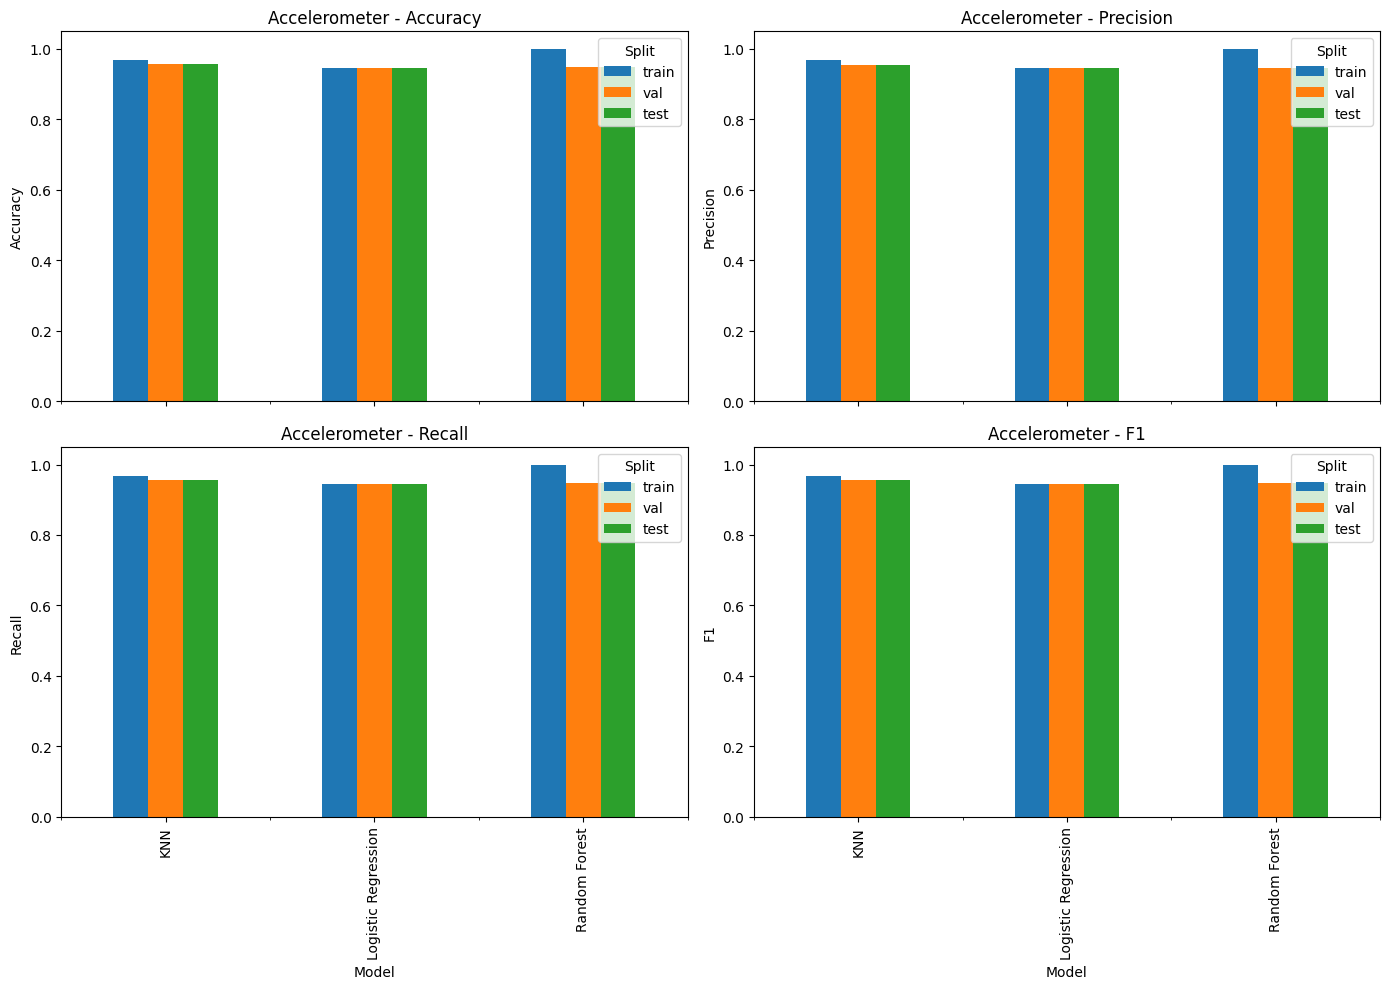

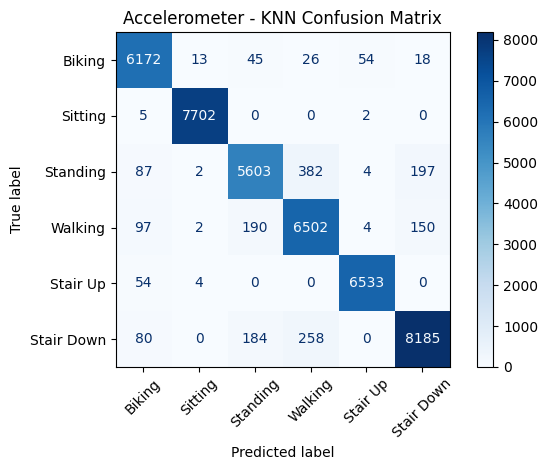

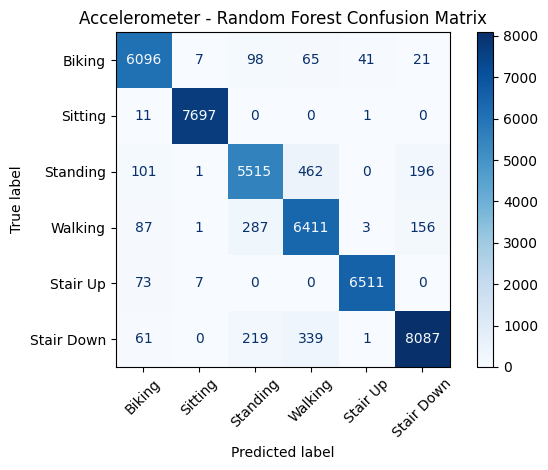

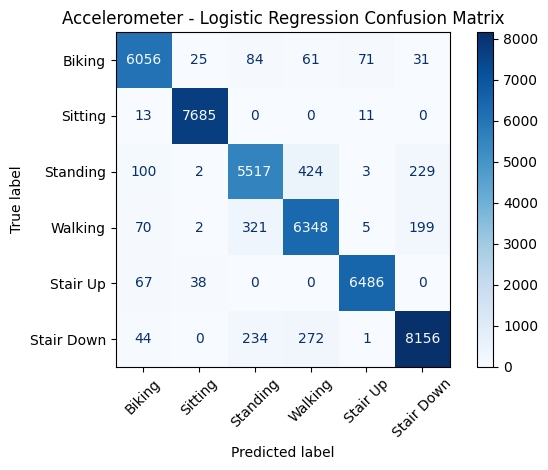

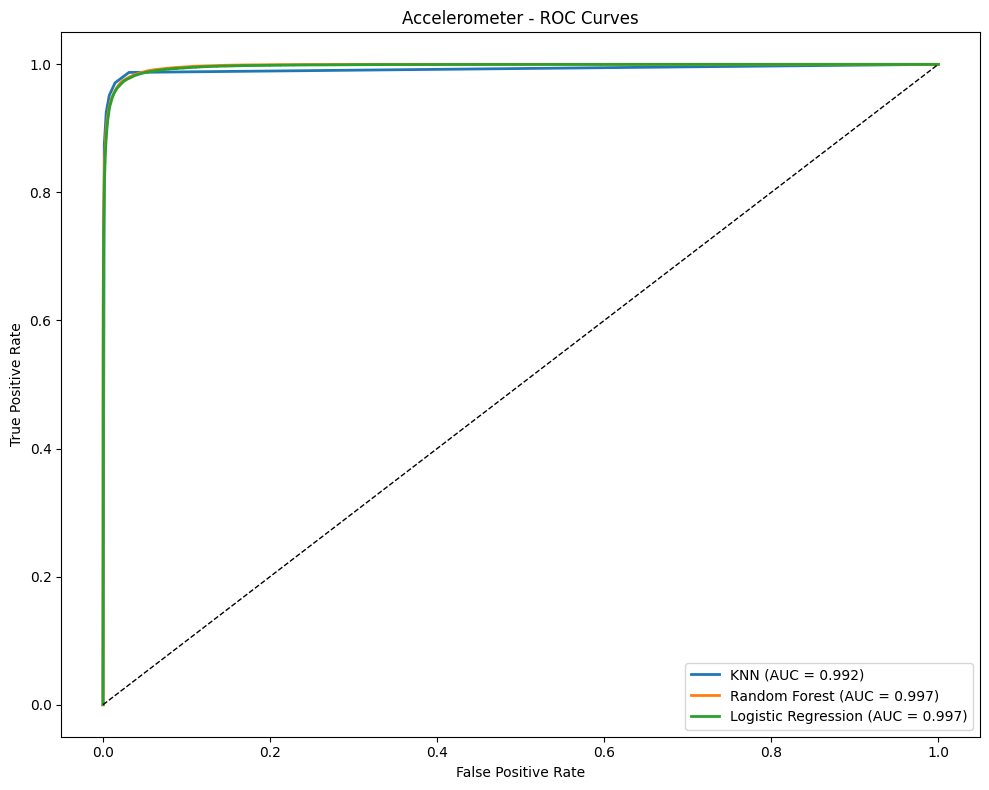

In [15]:
acc_test_results = test_models(acc_models, x_acc_test_scaled, y_acc_test, 'Accelerometer', class_dispname)
display(acc_test_results)
plot_split_scores(pd.concat([acc_val_results, acc_test_results], ignore_index=True), 'Accelerometer')
acc_top_models = plot_confusion_matrices(acc_models, x_acc_test_scaled, y_acc_test, 'Accelerometer', class_dispname)
plot_multiclass_roc(acc_models, x_acc_test_scaled, y_acc_test, 'Accelerometer', class_dispname)



=== Gyroscope: Logistic Regression - Test Set ===
              precision    recall  f1-score   support

      Biking       0.91      0.90      0.90      6764
     Sitting       0.73      0.87      0.80      8675
    Standing       0.86      0.85      0.86      6620
     Walking       0.89      0.90      0.89      7461
    Stair Up       0.79      0.62      0.69      7373
  Stair Down       0.93      0.92      0.93      9386

    accuracy                           0.85     46279
   macro avg       0.85      0.84      0.84     46279
weighted avg       0.85      0.85      0.85     46279


=== Gyroscope: Random Forest - Test Set ===
              precision    recall  f1-score   support

      Biking       0.92      0.91      0.92      6764
     Sitting       0.82      0.83      0.82      8675
    Standing       0.87      0.88      0.87      6620
     Walking       0.90      0.92      0.91      7461
    Stair Up       0.79      0.77      0.78      7373
  Stair Down       0.94      0.93   

,sensor,model,split,accuracy,precision,recall,f1
0,Gyroscope,Logistic Regression,test,0.847598,0.850802,0.844003,0.844657
1,Gyroscope,Random Forest,test,0.873377,0.872345,0.872993,0.872634
2,Gyroscope,KNN,test,0.868990,0.868944,0.868035,0.868337


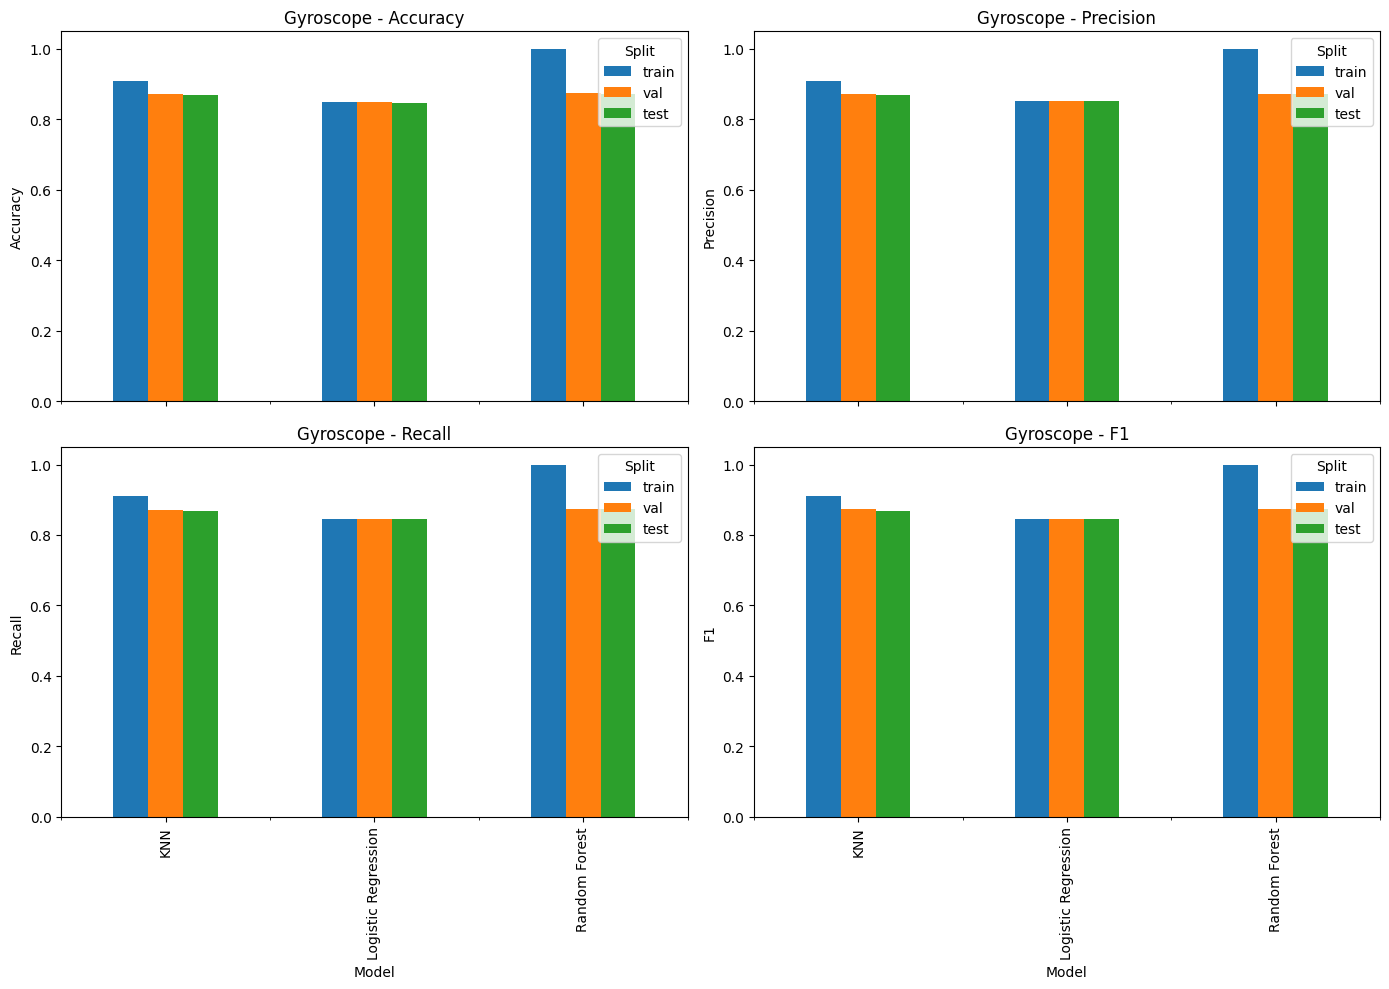

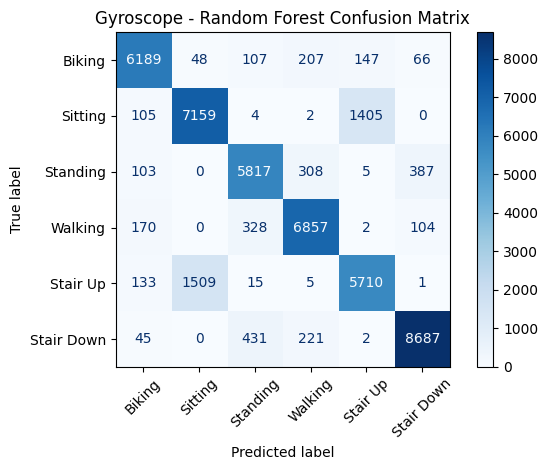

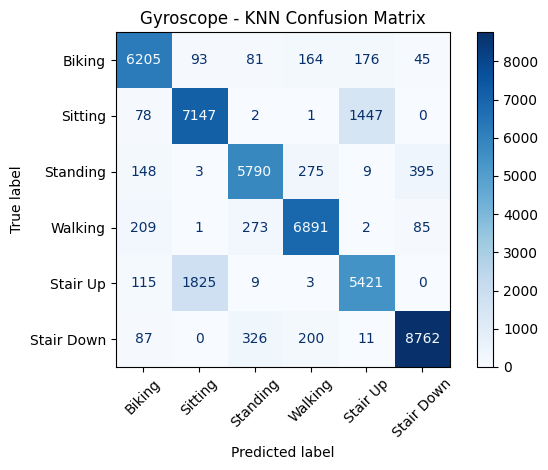

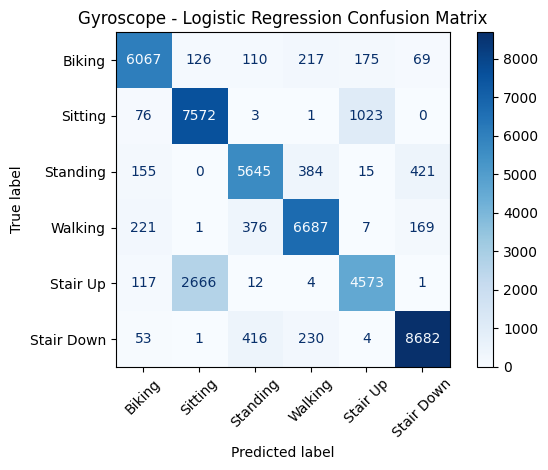

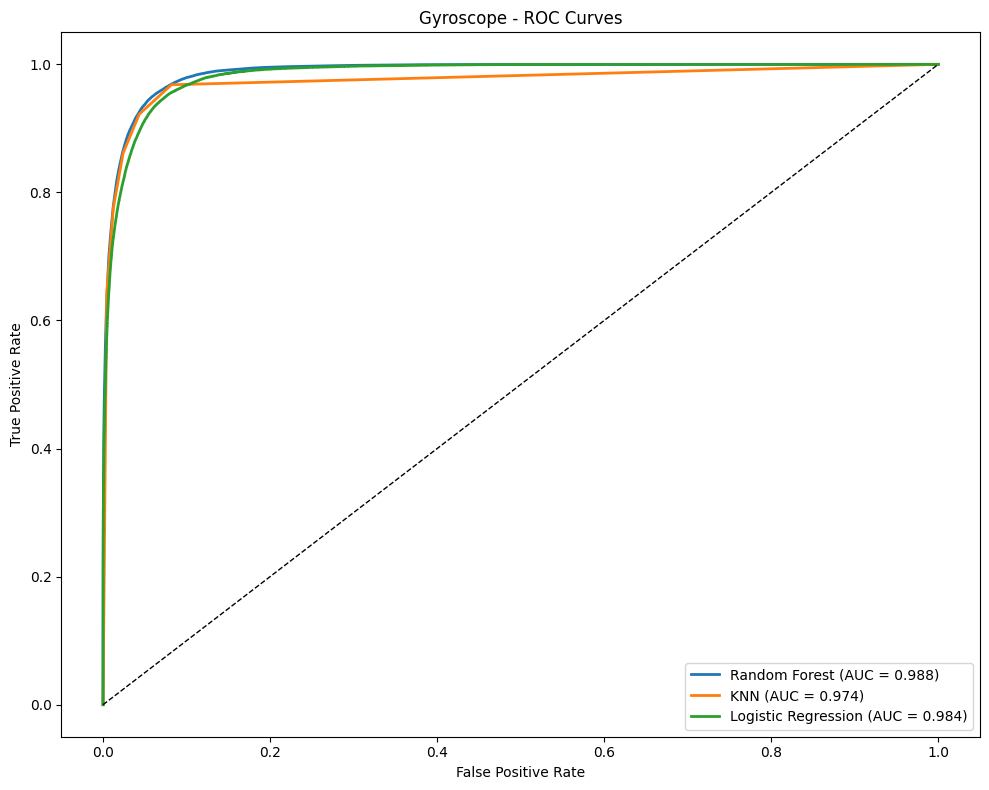

In [16]:
gyro_test_results = test_models(gyro_models, x_gyro_test_scaled, y_gyro_test, 'Gyroscope', class_dispname)
display(gyro_test_results)
plot_split_scores(pd.concat([gyro_val_results, gyro_test_results], ignore_index=True), 'Gyroscope')
gyro_top_models = plot_confusion_matrices(gyro_models, x_gyro_test_scaled, y_gyro_test, 'Gyroscope', class_dispname)
plot_multiclass_roc(gyro_models, x_gyro_test_scaled, y_gyro_test, 'Gyroscope', class_dispname)


In [17]:
# Compare the best test F1-score across phone sensors
acc_best_test = acc_test_results.sort_values('f1', ascending=False).drop_duplicates('model')
gyro_best_test = gyro_test_results.sort_values('f1', ascending=False).drop_duplicates('model')
comparison_test = pd.concat([
    acc_best_test.assign(sensor='Accelerometer'),
    gyro_best_test.assign(sensor='Gyroscope')
])
display(comparison_test[['sensor', 'model', 'accuracy', 'precision', 'recall', 'f1']].sort_values(['sensor', 'f1'], ascending=[True, False]))


,sensor,model,accuracy,precision,recall,f1
2,Accelerometer,KNN,0.956339,0.955445,0.955802,0.955480
1,Accelerometer,Random Forest,0.947409,0.946218,0.946738,0.946329
0,Accelerometer,Logistic Regression,0.945788,0.944599,0.944655,0.944588
1,Gyroscope,Random Forest,0.873377,0.872345,0.872993,0.872634
2,Gyroscope,KNN,0.868990,0.868944,0.868035,0.868337
0,Gyroscope,Logistic Regression,0.847598,0.850802,0.844003,0.844657


## Save Best Trained Models

This final section saves the best trained classifier for each sensor experiment, selected by testmacro F1-score.

In [18]:
import joblib

MODEL_DIR = Path('saved_models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def save_best_model(fitted_models, test_results_df, prefix):
    if test_results_df.empty:
        print(f'No test results found for {prefix}; skipping save.')
        return None

    best_row = test_results_df.sort_values('f1', ascending=False).iloc[0]
    best_model_name = best_row['model']
    best_model = fitted_models[best_model_name]

    safe_name = best_model_name.lower().replace(' ', '_')
    path = MODEL_DIR / f'{prefix}_best_{safe_name}.joblib'
    joblib.dump(best_model, path)
    print(f'Saved best model for {prefix}: {path.resolve()}')
    return path


saved_model_paths = []

for fitted_models_obj, results_df, prefix in [
    (acc_models, acc_test_results, 'phone_acc'),
    (gyro_models, gyro_test_results, 'phone_gyro'),
]:
    path = save_best_model(fitted_models_obj, results_df, prefix)
    if path is not None:
        saved_model_paths.append(path)

if 'watch_acc_models_v2' in globals() and 'watch_acc_test_results_v2' in globals():
    path = save_best_model(watch_acc_models_v2, watch_acc_test_results_v2, 'watch_acc')
    if path is not None:
        saved_model_paths.append(path)

if 'watch_gyro_models_v2' in globals() and 'watch_gyro_test_results_v2' in globals():
    path = save_best_model(watch_gyro_models_v2, watch_gyro_test_results_v2, 'watch_gyro')
    if path is not None:
        saved_model_paths.append(path)

print('Saved model files:')
for path in saved_model_paths:
    print(path.resolve())


Saved best model for phone_acc: C:\Users\suhur\Downloads\New folder (2)\saved_models\phone_acc_best_knn.joblib
Saved best model for phone_gyro: C:\Users\suhur\Downloads\New folder (2)\saved_models\phone_gyro_best_random_forest.joblib
Saved model files:
C:\Users\suhur\Downloads\New folder (2)\saved_models\phone_acc_best_knn.joblib
C:\Users\suhur\Downloads\New folder (2)\saved_models\phone_gyro_best_random_forest.joblib
